# ESC-50 Architecture Ablation Study — SpecTrans WGAN-GP
**4 Architecture Combinations Compared on Rain / Engine / Siren**

## Architecture Combinations

| ID | Generator | Reconstruction | Key Difference | When Better |
|---|---|---|---|---|
| **A** | Transformer (ViT) | Griffin-Lim | Global attention + iterative phase | Complex harmonic patterns |
| **B** | Transformer (ViT) | iSTFT (direct) | Global attention + learned phase | Phase-sensitive signals |
| **C** | CNN (Conv2DTranspose) | Griffin-Lim | Local conv features + iterative phase | Fast training, local freq patterns |
| **D** | CNN (Conv2DTranspose) | iSTFT (direct) | Local conv features + learned phase | Speed + phase quality |

## How Each Differs

### Generator Architecture
**Transformer (A, B):**
- Noise → staged Dense expansion → 256 patch tokens (4×4 each)
- 4× Transformer blocks with multi-head self-attention
- Each token attends to ALL 255 others simultaneously
- Captures global harmonic relationships (500Hz ↔ 1000Hz patch)
- ~2.2M parameters, slower to train

**CNN (C, D):**
- Noise → Dense(4×4×256) → Reshape → 4× Conv2DTranspose (stride=2)
- 4→8→16→32→64 spatial upsampling
- Local 4×4 kernels — nearby freq bins correlated
- No global attention — long-range relationships not directly modelled
- ~800K parameters, 3× faster to train

### Reconstruction Method
**Griffin-Lim (A, C):**
- Generator outputs 1 channel: log-magnitude only
- Phase estimated iteratively (32 iters, momentum=0.99)
- Phase always approximate → some smearing of sharp transients
- Proven approach, works well for stationary signals (rain, engine hum)

**iSTFT Direct (B, D):**
- Generator outputs 2 channels: log-magnitude + normalised phase
- Phase learned directly by the generator from data
- No iteration — reconstruction is a single iSTFT call
- Better for phase-sensitive signals (siren sweep, onset transients)
- Harder to train: generator must learn consistent phase relationships

## Pipeline
```
Steps 1–7: Preprocessing (runs ONCE — same data for all 4 combos)
  └─ Download ESC-50 → load WAV → segment → STFT → 64×64 spectrograms
  └─ Also compute 2-channel spectrograms (mag+phase) for combos B & D

Steps 8–11: Define ALL architectures (Transformer Gen, CNN Gen, Critic)

Step 12: Ablation loop — train 4 combos × 3 classes = 12 GANs total
  ├─ Combo A: TransformerGen → 1-ch spec → Griffin-Lim → audio
  ├─ Combo B: TransformerGen → 2-ch spec → iSTFT       → audio
  ├─ Combo C: CNNGen         → 1-ch spec → Griffin-Lim → audio
  └─ Combo D: CNNGen         → 2-ch spec → iSTFT       → audio

Steps 13–20: Evaluation per combo (loss curves, distribution, FFT, classifier)
Step 21: Comparison table — choose winner
```

## Step 1: Download ESC-50 Dataset
> Downloads the full ESC-50 zip (~600 MB) from GitHub.
> Extracts audio files for exactly 3 classes: rain, engine, siren.
> Each class has 40 recordings of 5 seconds at 44,100 Hz.

In [ ]:
import os, subprocess

if not os.path.exists('ESC-50-master'):
    print('Downloading ESC-50...')
    os.system('wget -q https://github.com/karolpiczak/ESC-50/archive/refs/heads/master.zip -O ESC-50.zip')
    os.system('unzip -q ESC-50.zip')
    print('Extracted.')
else:
    print('ESC-50 already downloaded.')

# Verify audio and metadata
audio_files = os.listdir('ESC-50-master/audio')
print(f'Total audio files : {len(audio_files)}')
print(f'Meta CSV exists   : {os.path.exists("ESC-50-master/meta/esc50.csv")}')


Extracted.
Total audio files : 2000
Meta CSV exists   : True


## Step 2: Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import stft, istft, resample_poly
from scipy.stats import kurtosis
from fractions import Fraction

!pip install -q librosa tensorflow
import librosa

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle as sk_shuffle
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import SpectralNormalization
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('All imports successful.')


TensorFlow version: 2.20.0
All imports successful.


## Step 3: Configuration
> ESC-50 native 44,100 Hz resampled to **8,000 Hz** — captures all relevant content:
> - Rain: 100–4,000 Hz broadband splash/patter
> - Engine: 50–1,000 Hz fundamental + harmonics
> - Siren: 500–2,000 Hz sweep pattern
>
> STFT scales [16, 32, 64] unchanged from bearing notebook — same architecture, different signal.

In [ ]:
# ── Data ──────────────────────────────────────────────────────────────────
SEQ_LEN        = 128          # samples per window (same as bearing)
WINDOW_STEP    = 16           # hop size — 87.5% overlap
ORIG_FS        = 44_100       # ESC-50 native sampling rate
TARGET_FS      = 8_000        # resample target — captures 0-4kHz (engine/rain/siren all present)

# ── 3 classes ─────────────────────────────────────────────────────────────
TARGET_CLASSES = ['rain', 'engine', 'siren']   # maximally distinct freq signatures
N_CLASSES      = len(TARGET_CLASSES)
CLASS_IDX      = {cls: i for i, cls in enumerate(TARGET_CLASSES)}

# ── Multi-scale STFT ──────────────────────────────────────────────────────
STFT_SCALES    = [16, 32, 64]  # same as bearing — works for 8kHz audio
SPEC_SIZE      = 64            # GAN input: (64, 64, 1)

MAX_SEQS_PER_CLASS = 3000    # cap sequences before STFT (was None = ~100K each)
MAX_GAN_SEQS       = 2000    # cap GAN training subset

# ── WGAN-GP ───────────────────────────────────────────────────────────────
NOISE_DIM      = 50
BATCH_SIZE     = 32
N_CRITIC       = 3
LAMBDA_GP      = 10
WGAN_EPOCHS    = 2000
EVAL_EVERY     = 10
N_SYNTHETIC    = 100           # per class — 3 classes × 100 = 300 total synthetic

# ── Transformer ───────────────────────────────────────────────────────────
PATCH_SIZE       = 4           # 4×4 patches → 16×16 = 256 tokens
D_MODEL          = 32
NUM_HEADS        = 4
DFF              = 64
NUM_TRANS_LAYERS = 4
DROPOUT_RATE     = 0.1

# ── Optimiser ─────────────────────────────────────────────────────────────
LR_GEN         = 0.0002
LR_CRIT        = 0.0001
BETA_1         = 0.0           # 0 recommended for WGAN-GP
BETA_2         = 0.999

# ── Classifier ────────────────────────────────────────────────────────────
CLF_EPOCHS     = 15
CLF_BATCH      = 64

RANDOM_SEED    = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('Configuration set.')
print(f'Classes           : {TARGET_CLASSES}')
print(f'GAN spectrogram   : ({SPEC_SIZE}, {SPEC_SIZE}, 1)')
print(f'STFT scales       : {STFT_SCALES}')
print(f'Segmentation      : window={SEQ_LEN}, step={WINDOW_STEP}')
print(f'Resampling        : {ORIG_FS} Hz -> {TARGET_FS} Hz')
print(f'WGAN epochs       : {WGAN_EPOCHS} | Batch: {BATCH_SIZE} | N_critic: {N_CRITIC}')
print(f'Transformer       : d={D_MODEL}, heads={NUM_HEADS}, layers={NUM_TRANS_LAYERS}')


Configuration set.
Classes           : ['rain', 'engine', 'siren']
GAN spectrogram   : (64, 64, 1)
STFT scales       : [16, 32, 64]
Segmentation      : window=128, step=16
Resampling        : 44100 Hz -> 8000 Hz
WGAN epochs       : 2000 | Batch: 32 | N_critic: 3
Transformer       : d=32, heads=4, layers=4


## Step 4: Load ESC-50 Audio Files
> Reads `esc50.csv` metadata to find files for each of the 3 target classes.
> Loads each WAV with `librosa.load` (resamples inline to TARGET_FS=8,000 Hz).
> Concatenates all recordings per class into one long 1-D signal.

In [ ]:
META_CSV   = 'ESC-50-master/meta/esc50.csv'
AUDIO_DIR  = 'ESC-50-master/audio'

df = pd.read_csv(META_CSV)
print('ESC-50 metadata loaded. Columns:', list(df.columns))
print('Available categories (sample):', sorted(df['category'].unique())[:15], '...')
print()

signals = {}   # {class_name: np.array (N,)}

for cls in TARGET_CLASSES:
    rows = df[df['category'] == cls]
    if len(rows) == 0:
        raise ValueError(f'Class "{cls}" not found in ESC-50. Check category spelling.')

    class_signals = []
    for fname in rows['filename'].values:
        y, _ = librosa.load(
            os.path.join(AUDIO_DIR, fname),
            sr=TARGET_FS,     # resample inline
            mono=True
        )
        class_signals.append(y)

    signals[cls] = np.concatenate(class_signals).astype(np.float32)
    n_files = len(rows)
    dur_s   = len(signals[cls]) / TARGET_FS
    print(f'  {cls:8s}: {n_files} files, {len(signals[cls]):,} samples, {dur_s:.1f}s total')

print(f'\nAll 3 classes loaded at {TARGET_FS} Hz.')


ESC-50 metadata loaded. Columns: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take']
Available categories (sample): ['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow', 'crackling_fire'] ...

  rain    : 40 files, 1,600,000 samples, 200.0s total
  engine  : 40 files, 1,600,000 samples, 200.0s total
  siren   : 40 files, 1,600,000 samples, 200.0s total

All 3 classes loaded at 8000 Hz.


## Step 5: Overlapping Segmentation & Train/Test Split

### Why overlapping segmentation (step=16)?
- step=16 on SEQ_LEN=128 → 87.5% overlap → ~8x more sequences per recording
- Each 128-sample window at 8,000 Hz = **16ms** of audio
- High overlap ensures GAN sees each sound event from multiple temporal perspectives
- Train/test split before scaling — scaler fit on training data only (no leakage)

In [ ]:
def create_sequences(signal, seq_len, step):
    seqs = []
    for i in range(0, len(signal) - seq_len, step):
        seqs.append(signal[i: i + seq_len])
    return np.array(seqs, dtype=np.float32)


# Create sequences per class
class_seqs = {}
for cls in TARGET_CLASSES:
    seqs = create_sequences(signals[cls], SEQ_LEN, WINDOW_STEP)
    class_seqs[cls] = seqs
    print(f'  {cls:8s}: {len(seqs):,} sequences')

# Cap per class before concatenation — prevents RAM explosion in STFT step
for cls in TARGET_CLASSES:
    if len(class_seqs[cls]) > MAX_SEQS_PER_CLASS:
        idx = np.random.choice(len(class_seqs[cls]),
                               MAX_SEQS_PER_CLASS, replace=False)
        class_seqs[cls] = class_seqs[cls][idx]
        print(f'  {cls:8s}: capped to {MAX_SEQS_PER_CLASS:,}')

# Build combined arrays with integer labels
X_list, y_list = [], []
for cls in TARGET_CLASSES:
    X_list.append(class_seqs[cls])
    y_list.append(np.full(len(class_seqs[cls]), CLASS_IDX[cls], dtype=np.int32))

X = np.concatenate(X_list)
y = np.concatenate(y_list)

print(f'\nTotal sequences: {len(X):,}')
for cls in TARGET_CLASSES:
    n = (y == CLASS_IDX[cls]).sum()
    print(f'  Class {CLASS_IDX[cls]} ({cls:8s}): {n:,}')

# ── Split BEFORE scaling ─────────────────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Fit on train only
x_min = float(X_train_raw.min())
x_max = float(X_train_raw.max())
X_train_scaled = (2.0*(X_train_raw - x_min)/(x_max - x_min + 1e-8) - 1.0).astype(np.float32)
X_test_scaled  = (2.0*(X_test_raw  - x_min)/(x_max - x_min + 1e-8) - 1.0).astype(np.float32)

print(f'\nTrain: {X_train_scaled.shape[0]:,} | Test: {X_test_scaled.shape[0]:,}')
print(f'Value range: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]')


  rain    : 99,992 sequences
  engine  : 99,992 sequences
  siren   : 99,992 sequences
  rain    : capped to 3,000
  engine  : capped to 3,000
  siren   : capped to 3,000

Total sequences: 9,000
  Class 0 (rain    ): 3,000
  Class 1 (engine  ): 3,000
  Class 2 (siren   ): 3,000

Train: 7,200 | Test: 1,800
Value range: [-1.00, 1.00]


## Step 6: Multi-Scale STFT → 64×64 Log Spectrograms

### Why multi-scale STFT for audio?
- nperseg=16 → 2ms frames → captures rain drop transients and engine cylinder events
- nperseg=32 → 4ms frames → captures siren sweep rate and engine harmonics
- nperseg=64 → 8ms frames → resolves individual harmonics of engine fundamental
- Averaging 3 scales gives complementary resolution at all frequencies simultaneously

### Signal content at 8,000 Hz per class
- **Rain:** broadband 200-4000 Hz, no clear harmonics, stochastic
- **Engine:** strong fundamental 50-300 Hz + harmonic series to 2kHz, quasi-periodic
- **Siren:** sweeping tone 500-2000 Hz, distinctive time-frequency trajectory

In [ ]:
def compute_multiscale_spectrogram(seq, scales=STFT_SCALES,
                                   target_size=SPEC_SIZE, fs=TARGET_FS):
    averaged = np.zeros((target_size, target_size), dtype=np.float32)
    for nperseg in scales:
        noverlap = nperseg // 2
        _, _, Zxx = stft(seq, fs=fs, nperseg=nperseg,
                         noverlap=noverlap, boundary='zeros')
        mag  = np.abs(Zxx).astype(np.float32)
        mag  = np.log1p(mag)
        mag_4d = mag[np.newaxis, :, :, np.newaxis]
        mag_r  = tf.image.resize(mag_4d, [target_size, target_size],
                                  method='bilinear').numpy()
        averaged += mag_r[0, :, :, 0]
    return averaged / len(scales)


def batch_compute_spectrograms(sequences, scales=STFT_SCALES,
                               target_size=SPEC_SIZE, fs=TARGET_FS):
    out = np.zeros((len(sequences), target_size, target_size), dtype=np.float32)
    for i, seq in enumerate(sequences):
        out[i] = compute_multiscale_spectrogram(seq, scales, target_size, fs)
        if (i + 1) % 10000 == 0:
            print(f'  Processed {i+1}/{len(sequences)}...')
    return out


print(f'Computing multi-scale spectrograms (scales={STFT_SCALES}) -> {SPEC_SIZE}x{SPEC_SIZE}...')
S_train_raw = batch_compute_spectrograms(X_train_scaled)
S_test_raw  = batch_compute_spectrograms(X_test_scaled)
print(f'Train: {S_train_raw.shape}  Test: {S_test_raw.shape}')

# Scale to [-1, 1] using train stats only
s_min = float(S_train_raw.min())
s_max = float(S_train_raw.max())

def scale_spec(s):
    return (2.0*(s - s_min)/(s_max - s_min + 1e-8) - 1.0).astype(np.float32)

def unscale_spec(s):
    return ((s + 1.0)/2.0*(s_max - s_min) + s_min).astype(np.float32)

S_train = scale_spec(S_train_raw)[..., np.newaxis]   # (N, 64, 64, 1)
S_test  = scale_spec(S_test_raw)[..., np.newaxis]

# Per-class spectrogram tensors for GAN training
class_tensors = {}
for cls in TARGET_CLASSES:
    idx_c = CLASS_IDX[cls]
    S_c   = S_train[y_train == idx_c]
    S_c   = S_c if MAX_GAN_SEQS is None else S_c[:MAX_GAN_SEQS]
    class_tensors[cls] = tf.constant(S_c, dtype=tf.float32)
    print(f'  {cls:8s} GAN input: {S_c.shape[0]:,} spectrograms')

print(f'\nSpectrogram shape: {S_train.shape[1:]}')
print(f'Value range      : [{S_train.min():.2f}, {S_train.max():.2f}]')

import gc
del S_train_raw, S_test_raw
gc.collect()
print('Raw arrays freed.')


Computing multi-scale spectrograms (scales=[16, 32, 64]) -> 64x64...
Train: (7200, 64, 64)  Test: (1800, 64, 64)
  rain     GAN input: 2,000 spectrograms
  engine   GAN input: 2,000 spectrograms
  siren    GAN input: 2,000 spectrograms

Spectrogram shape: (64, 64, 1)
Value range      : [-1.00, 1.00]
Raw arrays freed.


## Step 6b: Griffin-Lim Reconstruction Function
> Uses finest scale (nperseg=64) at 8,000 Hz — captures up to 4,000 Hz.
> Momentum=0.99 reduces phase smearing → reconstructed audio sounds cleaner.
> 64 iterations — verified to produce intelligible audio for these signal types.

In [ ]:
def griffin_lim_reconstruct(log_mag_64, n_iter=64,
                            fs=TARGET_FS, seq_len=SEQ_LEN,
                            momentum=0.99):
    nperseg  = STFT_SCALES[-1]       # 64
    noverlap = nperseg // 2          # 32
    native_f = nperseg // 2 + 1      # 33 freq bins

    mag = np.expm1(np.clip(log_mag_64, 0, None)).astype(np.float64)

    mag_4d     = mag[np.newaxis, :, :, np.newaxis]
    mag_native = tf.image.resize(mag_4d, [native_f, mag_4d.shape[2]],
                                  method='bilinear').numpy()[0, :, :, 0]

    phase      = np.exp(1j * np.random.uniform(0, 2*np.pi, mag_native.shape))
    prev_phase = phase.copy()

    for _ in range(n_iter):
        _, x      = istft(mag_native * phase, fs=fs,
                           nperseg=nperseg, noverlap=noverlap, boundary=True)
        _, _, Zxx = stft(x, fs=fs, nperseg=nperseg,
                          noverlap=noverlap, boundary='zeros')
        min_t     = min(Zxx.shape[1], mag_native.shape[1])
        new_phase = np.exp(1j * np.angle(Zxx[:, :min_t]))
        if Zxx.shape[1] < mag_native.shape[1]:
            pad       = np.ones((new_phase.shape[0],
                                  mag_native.shape[1] - min_t), dtype=complex)
            new_phase = np.concatenate([new_phase, pad], axis=1)
        phase      = new_phase + momentum * (new_phase - prev_phase)
        phase      = phase / (np.abs(phase) + 1e-8)
        prev_phase = new_phase

    _, signal = istft(mag_native * phase, fs=fs,
                       nperseg=nperseg, noverlap=noverlap, boundary=True)
    signal = signal.real.astype(np.float32)
    if len(signal) >= seq_len:
        return signal[:seq_len]
    return np.pad(signal, (0, seq_len - len(signal)))


print('Griffin-Lim with momentum defined.')
print(f'  Finest scale : nperseg={STFT_SCALES[-1]} @ {TARGET_FS} Hz')
print(f'  Output length: {SEQ_LEN} samples = {SEQ_LEN/TARGET_FS*1000:.1f} ms')


Griffin-Lim with momentum defined.
  Finest scale : nperseg=64 @ 8000 Hz
  Output length: 128 samples = 16.0 ms


## Step 7: Verify Preprocessing Shapes

In [ ]:
print('=' * 55)
print('PREPROCESSING VERIFICATION')
print('=' * 55)
print(f'X_train_scaled : {X_train_scaled.shape}')
print(f'X_test_scaled  : {X_test_scaled.shape}')
print(f'S_train        : {S_train.shape}  <- (N, 64, 64, 1)')
print(f'S_test         : {S_test.shape}')
for cls in TARGET_CLASSES:
    print(f'  class_tensors[{cls}]: {class_tensors[cls].shape}')
print(f'Value range    : [{float(S_train.min()):.3f}, {float(S_train.max()):.3f}]')
for cls in TARGET_CLASSES:
    n = (y_train == CLASS_IDX[cls]).sum()
    print(f'  y_train {cls}: {n:,}')
assert S_train.shape[1] == SPEC_SIZE
assert S_train.shape[2] == SPEC_SIZE
assert S_train.shape[3] == 1
print('\nAll assertions passed. Safe to build Generator and Critic.')


PREPROCESSING VERIFICATION
X_train_scaled : (7200, 128)
X_test_scaled  : (1800, 128)
S_train        : (7200, 64, 64, 1)  <- (N, 64, 64, 1)
S_test         : (1800, 64, 64, 1)
  class_tensors[rain]: (2000, 64, 64, 1)
  class_tensors[engine]: (2000, 64, 64, 1)
  class_tensors[siren]: (2000, 64, 64, 1)
Value range    : [-1.000, 1.000]
  y_train rain: 2,400
  y_train engine: 2,400
  y_train siren: 2,400

All assertions passed. Safe to build Generator and Critic.


## Step 8: Transformer Building Blocks

In [ ]:
def positional_encoding(seq_len, d_model):
    positions = np.arange(seq_len)[:, np.newaxis]
    dims      = np.arange(d_model)[np.newaxis, :]
    angles    = positions / np.power(10000, (2 * (dims // 2)) / d_model)
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(angles[np.newaxis, :, :], tf.float32)


class TransformerEncoderBlock(layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.attn  = layers.MultiHeadAttention(
                         num_heads=num_heads,
                         key_dim=d_model // num_heads,
                         dropout=dropout_rate)
        self.ffn   = tf.keras.Sequential([
            layers.Dense(dff, activation='gelu'),
            layers.Dropout(dropout_rate),
            layers.Dense(d_model),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout_rate)
        self.drop2 = layers.Dropout(dropout_rate)

    def call(self, x, training=False):
        x_norm   = self.norm1(x)
        attn_out = self.attn(x_norm, x_norm, training=training)
        x        = x + self.drop1(attn_out, training=training)
        x_norm   = self.norm2(x)
        ffn_out  = self.ffn(x_norm, training=training)
        return x + self.drop2(ffn_out, training=training)


print('Transformer building blocks defined.')


Transformer building blocks defined.


## Step 9: All Generator Architectures
> Two generator types defined here. `build_generator(gen_type, out_channels)` factory
> returns the correct one. `out_channels=1` for Griffin-Lim, `out_channels=2` for iSTFT.

In [ ]:
# ── Patch constants ──────────────────────────────────────────────────────
N_PATCHES_SIDE = SPEC_SIZE // PATCH_SIZE    # 16
N_PATCHES      = N_PATCHES_SIDE ** 2        # 256 tokens
patch_dim      = PATCH_SIZE * PATCH_SIZE    # 16 values per patch

print(f'Patch config: PATCH_SIZE={PATCH_SIZE}, N_PATCHES={N_PATCHES}')


# ════════════════════════════════════════════════════════════════════════
# GENERATOR A/B: Transformer (Patch-ViT)
# Global self-attention across 256 patch tokens
# Captures long-range harmonic relationships
# ════════════════════════════════════════════════════════════════════════
def build_transformer_generator(
        noise_dim=NOISE_DIM, spec_size=SPEC_SIZE,
        patch_size=PATCH_SIZE, d_model=D_MODEL,
        num_heads=NUM_HEADS, dff=DFF,
        num_layers=NUM_TRANS_LAYERS, dropout_rate=DROPOUT_RATE,
        out_channels=1):
    n_side    = spec_size // patch_size
    n_tokens  = n_side * n_side
    patch_d   = patch_size * patch_size
    pos_enc   = positional_encoding(n_tokens, d_model)

    inp = Input(shape=(noise_dim,), name='noise')
    x   = layers.Dense(256, activation='gelu', kernel_initializer='he_normal')(inp)
    x   = layers.Dense(512, activation='gelu', kernel_initializer='he_normal')(x)
    x   = layers.Dense(n_tokens * d_model, activation='gelu',
                       kernel_initializer='he_normal')(x)
    x   = layers.Reshape((n_tokens, d_model))(x)
    x   = x + pos_enc
    x   = layers.Dropout(dropout_rate)(x)

    for i in range(num_layers):
        x = TransformerEncoderBlock(
                d_model=d_model, num_heads=num_heads,
                dff=dff, dropout_rate=dropout_rate,
                name=f'gen_trans_{i}')(x)

    x   = layers.LayerNormalization(epsilon=1e-6)(x)
    x   = layers.Dense(patch_d, activation='linear',
                       kernel_initializer='glorot_normal')(x)
    x   = layers.Reshape((n_side, n_side, patch_size, patch_size))(x)
    x   = layers.Lambda(
              lambda t: tf.reshape(tf.transpose(t, [0,1,3,2,4]),
                                   [-1, spec_size, spec_size]),
              name='patch_fold')(x)
    x   = layers.Lambda(lambda t: tf.reverse(t, axis=[1]),
              name='freq_flip')(x)
    x   = layers.Reshape((spec_size, spec_size, 1))(x)

    # Expand to out_channels if iSTFT mode
    if out_channels == 2:
        x = layers.Conv2D(2, 1, activation='tanh',
                          name='spectrogram_out')(x)
    else:
        x = layers.Activation('tanh', name='spectrogram_out')(x)

    return Model(inp, x, name=f'TransformerGen_{out_channels}ch')


# ════════════════════════════════════════════════════════════════════════
# GENERATOR C/D: CNN (Conv2DTranspose upsampling)
# Local conv features: 4→8→16→32→64 via stride-2 upsample
# No global attention — 3× faster, good for local freq patterns
# ════════════════════════════════════════════════════════════════════════
def build_cnn_generator(
        noise_dim=NOISE_DIM, spec_size=SPEC_SIZE,
        out_channels=1):
    inp = Input(shape=(noise_dim,), name='noise')

    x = layers.Dense(4 * 4 * 256, activation='relu',
                     kernel_initializer='he_normal')(inp)
    x = layers.Reshape((4, 4, 256))(x)                           # 4×4

    # 4 upsampling blocks: 4→8→16→32→64
    for filters in [128, 64, 32, 16]:
        x = layers.Conv2DTranspose(filters, 4, strides=2,
                                   padding='same',
                                   kernel_initializer='he_normal')(x)
        x = layers.LayerNormalization()(x)
        x = layers.Activation('relu')(x)

    out = layers.Conv2D(out_channels, 1, activation='tanh',
                        kernel_initializer='he_normal',
                        name='spectrogram_out')(x)

    return Model(inp, out, name=f'CNNGen_{out_channels}ch')


def build_generator(gen_type, out_channels=1):
    """Factory: returns correct generator for combo."""
    if gen_type == 'transformer':
        return build_transformer_generator(out_channels=out_channels)
    else:
        return build_cnn_generator(out_channels=out_channels)


# ── Print param counts for both ───────────────────────────────────────────
for gt in ['transformer', 'cnn']:
    for oc in [1, 2]:
        g = build_generator(gt, oc)
        print(f'  {gt:12s} {oc}ch: {g.count_params():>8,} params | output: {g.output_shape}')
        del g


# ════════════════════════════════════════════════════════════════════════
# RECONSTRUCTION: iSTFT (direct — no iteration)
# Generator output ch0=log_mag, ch1=phase_normalised→[-1,1]
# Reconstruction: complex = mag * exp(i * phase*π) → single iSTFT
# ════════════════════════════════════════════════════════════════════════
def istft_reconstruct(mag_phase_64, fs=TARGET_FS, seq_len=SEQ_LEN):
    nperseg  = STFT_SCALES[-1]
    noverlap = nperseg // 2
    native_f = nperseg // 2 + 1

    log_mag    = unscale_spec(mag_phase_64[:, :, 0])
    mag        = np.expm1(np.clip(log_mag, 0, None)).astype(np.float64)
    phase_rad  = (mag_phase_64[:, :, 1] * np.pi).astype(np.float64)

    def rz(arr):
        a4 = arr[np.newaxis, :, :, np.newaxis]
        return tf.image.resize(a4, [native_f, a4.shape[2]],
                               method='bilinear').numpy()[0, :, :, 0]

    Zxx = rz(mag) * np.exp(1j * rz(phase_rad))
    _, signal = istft(Zxx, fs=fs, nperseg=nperseg,
                      noverlap=noverlap, boundary=True)
    signal = signal.real.astype(np.float32)
    return signal[:seq_len] if len(signal) >= seq_len \
           else np.pad(signal, (0, seq_len - len(signal)))


# ════════════════════════════════════════════════════════════════════════
# 2-channel spectrogram (magnitude + phase) for iSTFT training
# ════════════════════════════════════════════════════════════════════════
def compute_2ch_spectrogram(seq, scales=STFT_SCALES,
                             target_size=SPEC_SIZE, fs=TARGET_FS):
    avg_mag   = np.zeros((target_size, target_size), dtype=np.float32)
    avg_phase = np.zeros((target_size, target_size), dtype=np.float32)

    for nperseg in scales:
        noverlap  = nperseg // 2
        _, _, Zxx = stft(seq, fs=fs, nperseg=nperseg,
                         noverlap=noverlap, boundary='zeros')
        mag   = np.log1p(np.abs(Zxx)).astype(np.float32)
        phase = (np.angle(Zxx) / np.pi).astype(np.float32)

        def rs(arr):
            a4 = arr[np.newaxis, :, :, np.newaxis]
            return tf.image.resize(a4, [target_size, target_size],
                                   method='bilinear').numpy()[0, :, :, 0]
        avg_mag   += rs(mag)
        avg_phase += rs(phase)

    return np.stack([avg_mag/len(scales), avg_phase/len(scales)], axis=-1)


print('All generator architectures and reconstruction functions defined.')


Patch config: PATCH_SIZE=4, N_PATCHES=256
  transformer  1ch: 4,381,904 params | output: (None, 64, 64, 1)
  transformer  2ch: 4,381,908 params | output: (None, 64, 64, 2)
  cnn          1ch:  905,953 params | output: (None, 64, 64, 1)
  cnn          2ch:  905,970 params | output: (None, 64, 64, 2)
All generator architectures and reconstruction functions defined.


## Step 10: Build Conv2D Critic
> Same critic used for ALL 4 combos — `in_channels` param handles 1-ch vs 2-ch input.
> SpectralNorm on Block 1. 4-block: 64→32→16→8→GlobalAvgPool.

In [ ]:
def build_conv_critic(spec_size=SPEC_SIZE, in_channels=1):
    """
    4-block Conv2D critic.
    in_channels=1 for Griffin-Lim combos (A, C)
    in_channels=2 for iSTFT combos (B, D) — critic sees mag+phase
    """
    inp = Input(shape=(spec_size, spec_size, in_channels), name='spectrogram_in')

    x = SpectralNormalization(
        layers.Conv2D(32, kernel_size=4, strides=1, padding='same',
                      kernel_initializer='he_normal'))(inp)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(64, kernel_size=4, strides=2, padding='same',
                      kernel_initializer='he_normal')(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128, kernel_size=4, strides=2, padding='same',
                      kernel_initializer='he_normal')(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(256, kernel_size=4, strides=2, padding='same',
                      kernel_initializer='he_normal')(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(64, kernel_initializer='he_normal')(x)
    x   = layers.LeakyReLU(0.2)(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1, kernel_initializer='he_normal')(x)

    return Model(inp, out, name=f'ConvCritic_{in_channels}ch')


for ch in [1, 2]:
    c = build_conv_critic(in_channels=ch)
    print(f'  Critic {ch}ch: {c.count_params():,} params | input: {c.input_shape}')
    del c


  Critic 1ch: 706,561 params | input: (None, 64, 64, 1)
  Critic 2ch: 707,073 params | input: (None, 64, 64, 2)


## Step 11: WGAN-GP Training Functions

In [ ]:
import gc

def gradient_penalty(critic, real_specs, fake_specs):
    eps   = tf.random.uniform([tf.shape(real_specs)[0], 1, 1, 1], 0.0, 1.0)
    x_hat = eps * real_specs + (1.0 - eps) * fake_specs
    with tf.GradientTape() as tape:
        tape.watch(x_hat)
        d_hat = critic(x_hat, training=True)
    grads      = tape.gradient(d_hat, x_hat)
    grad_norms = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1,2,3]) + 1e-8)
    return tf.reduce_mean((grad_norms - 1.0) ** 2)


def make_train_functions(generator, critic, gen_opt, crit_opt):
    @tf.function
    def train_critic_step(real_batch):
        noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])
        with tf.GradientTape() as tape:
            fake       = generator(noise, training=True)
            real_score = critic(real_batch, training=True)
            fake_score = critic(fake,       training=True)
            gp         = gradient_penalty(critic, real_batch, fake)
            c_loss     = (tf.reduce_mean(fake_score)
                          - tf.reduce_mean(real_score)
                          + LAMBDA_GP * gp)
        c_grads = tape.gradient(c_loss, critic.trainable_variables)
        crit_opt.apply_gradients(zip(c_grads, critic.trainable_variables))
        return c_loss, tf.reduce_mean(real_score), tf.reduce_mean(fake_score)

    @tf.function
    def train_generator_step():
        noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])
        with tf.GradientTape() as tape:
            fake       = generator(noise, training=True)
            fake_score = critic(fake, training=True)
            g_loss     = -tf.reduce_mean(fake_score)
        g_grads = tape.gradient(g_loss, generator.trainable_variables)
        gen_opt.apply_gradients(zip(g_grads, generator.trainable_variables))
        return g_loss

    return train_critic_step, train_generator_step


def reconstruct_audio(specs, recon_type, cls):
    """Reconstruct synthetic time-domain audio from spectrogram batch."""
    idx_c    = CLASS_IDX[cls]
    n        = len(specs)
    X_td     = np.zeros((n, SEQ_LEN), dtype=np.float32)
    CHUNK    = 25

    for start in range(0, n, CHUNK):
        end = min(start + CHUNK, n)
        for i in range(start, end):
            if recon_type == 'istft':
                X_td[i] = istft_reconstruct(specs[i])          # 2-ch direct
            else:
                log_mag  = unscale_spec(specs[i, :, :, 0])
                X_td[i]  = griffin_lim_reconstruct(log_mag, n_iter=32)  # 1-ch iterative
        gc.collect()

    # RMS-matched scaling
    X_real   = X_train_scaled[y_train == idx_c]
    rms_r    = np.sqrt(np.mean(X_real**2, axis=1))
    target   = np.random.normal(rms_r.mean(), rms_r.std(),
                 (n,1)).clip(rms_r.mean()*0.3, rms_r.mean()*2.0).astype(np.float32)
    s_rms    = np.sqrt(np.mean(X_td**2, axis=1, keepdims=True))
    safe     = np.where(s_rms < 1e-8, 1.0, s_rms)
    X_td     = np.clip(X_td * (target/safe).clip(0.5, 1.5), -1.0, 1.0)
    return X_td


def train_one_combo(cls, gen_type, recon_type,
                    class_tensors_1ch, class_tensors_2ch,
                    epochs=WGAN_EPOCHS):
    """Train one GAN for one class+combo. Returns generator, history, audio."""
    out_ch = 2 if recon_type == 'istft' else 1
    data   = class_tensors_2ch[cls] if recon_type == 'istft' \
             else class_tensors_1ch[cls]

    gen      = build_generator(gen_type, out_ch)
    crit     = build_conv_critic(in_channels=out_ch)
    gen_opt  = Adam(LR_GEN,  beta_1=BETA_1, beta_2=BETA_2, clipnorm=1.0)
    crit_opt = Adam(LR_CRIT, beta_1=BETA_1, beta_2=BETA_2, clipnorm=1.0)

    train_c, train_g = make_train_functions(gen, crit, gen_opt, crit_opt)
    n   = data.shape[0]
    hist = {'c':[], 'g':[], 'wd':[]}

    for epoch in range(1, epochs+1):
        c_losses = []
        for _ in range(N_CRITIC):
            idx   = np.random.randint(0, n, BATCH_SIZE)
            batch = tf.gather(data, idx)
            c_loss, r_score, f_score = train_c(batch)
            c_losses.append(float(c_loss))
        g_loss = train_g()
        w_dist = float(r_score) - float(f_score)
        hist['c'].append(float(np.mean(c_losses)))
        hist['g'].append(float(g_loss))
        hist['wd'].append(w_dist)
        if epoch % EVAL_EVERY == 0:
            print(f'    E{epoch:4d} C:{np.mean(c_losses):6.2f} '
                  f'G:{float(g_loss):6.2f} W:{w_dist:5.2f}', end='\r')

    # Generate synthetic
    noise = tf.random.normal([N_SYNTHETIC, NOISE_DIM])
    specs = gen(noise, training=False).numpy()
    audio = reconstruct_audio(specs, recon_type, cls)

    del crit, gen_opt, crit_opt, specs
    gc.collect()
    print(f'    [{cls}] done — final W_dist: {hist["wd"][-1]:.3f}')
    return gen, hist, audio


print('Training functions ready.')


Training functions ready.


## Step 11b: Precompute 2-Channel Spectrograms
> Needed for iSTFT combos (B, D). Magnitude channel uses same scaling as 1-ch.
> Phase channel is in [-1, 1] (angle/π). Done once — reused by both B and D.

In [ ]:
print('Precomputing 2-channel spectrograms (magnitude + phase) for iSTFT combos...')

class_tensors_2ch = {}

for cls in TARGET_CLASSES:
    idx_c    = CLASS_IDX[cls]
    seqs_c   = X_train_scaled[y_train == idx_c]
    n        = min(len(seqs_c), MAX_GAN_SEQS if MAX_GAN_SEQS else len(seqs_c))
    seqs_c   = seqs_c[:n]

    S2 = np.zeros((n, SPEC_SIZE, SPEC_SIZE, 2), dtype=np.float32)
    for i, seq in enumerate(seqs_c):
        S2[i] = compute_2ch_spectrogram(seq)
        if (i+1) % 300 == 0:
            print(f'  {cls}: {i+1}/{n}', end='\r')

    # Scale magnitude channel using existing s_min/s_max (from 1-ch STFT)
    S2[..., 0] = scale_spec(S2[..., 0])
    # Phase channel already in [-1,1] — no further scaling
    class_tensors_2ch[cls] = tf.constant(S2, dtype=tf.float32)
    print(f'  {cls}: 2-ch tensor {S2.shape}')
    del S2; gc.collect()

print('2-channel tensors ready.')


Precomputing 2-channel spectrograms (magnitude + phase) for iSTFT combos...
  rain: 2-ch tensor (2000, 64, 64, 2)
  engine: 2-ch tensor (2000, 64, 64, 2)
  siren: 2-ch tensor (2000, 64, 64, 2)
2-channel tensors ready.


## Step 12: Ablation Training Loop
> 4 combos × 3 classes = 12 GANs trained sequentially.
> Each combo stored in `ablation_results[combo_id][cls]`.
> **To run only one combo:** comment out the others in COMBOS list.
> **For full evaluation:** WGAN_EPOCHS=500 first, then re-run winner at 2000.

In [ ]:
# ── Architecture combinations ─────────────────────────────────────────────
# Comment out any combo to skip it
COMBOS = [
    ('transformer', 'griffin_lim', 'A',
     'Transformer + Griffin-Lim  (global attn, iterative phase)'),
    ('transformer', 'istft',       'B',
     'Transformer + iSTFT        (global attn, learned phase)'),
    ('cnn',         'griffin_lim', 'C',
     'CNN          + Griffin-Lim  (local conv,  iterative phase)'),
    ('cnn',         'istft',       'D',
     'CNN          + iSTFT        (local conv,  learned phase)'),
]

ablation_results = {}   # {combo_id: {cls: {'gen','hist','audio'}}}

for gen_type, recon_type, combo_id, description in COMBOS:
    print(f'\n{"="*65}')
    print(f'  COMBO {combo_id}: {description}')
    print(f'  Generator params: {build_generator(gen_type, 2 if recon_type=="istft" else 1).count_params():,}')
    print(f'{"="*65}')

    ablation_results[combo_id] = {}

    for cls in TARGET_CLASSES:
        print(f'\n  >> Class: {cls}')
        gen, hist, audio = train_one_combo(
            cls, gen_type, recon_type,
            class_tensors, class_tensors_2ch,
            epochs=WGAN_EPOCHS
        )
        ablation_results[combo_id][cls] = {
            'gen':   gen,
            'hist':  hist,
            'audio': audio,
        }
        del gen; gc.collect()

    print(f'\n  COMBO {combo_id} complete.')

print('\nAll combos trained. ablation_results keys:', list(ablation_results.keys()))



  COMBO A: Transformer + Griffin-Lim  (global attn, iterative phase)
  Generator params: 4,381,904

  >> Class: rain
    [rain] done — final W_dist: -0.334

  >> Class: engine
    [engine] done — final W_dist: -0.478

  >> Class: siren
    [siren] done — final W_dist: 0.718

  COMBO A complete.

  COMBO B: Transformer + iSTFT        (global attn, learned phase)
  Generator params: 4,381,908

  >> Class: rain
    [rain] done — final W_dist: 16.170

  >> Class: engine
    [engine] done — final W_dist: 0.167

  >> Class: siren
    [siren] done — final W_dist: 5.598

  COMBO B complete.

  COMBO C: CNN          + Griffin-Lim  (local conv,  iterative phase)
  Generator params: 905,953

  >> Class: rain
    [rain] done — final W_dist: 0.959

  >> Class: engine
    [engine] done — final W_dist: 0.753

  >> Class: siren
    [siren] done — final W_dist: 1.200

  COMBO C complete.

  COMBO D: CNN          + iSTFT        (local conv,  learned phase)
  Generator params: 905,970

  >> Class: rain


## Step 13: Training Loss Curves (all combos)

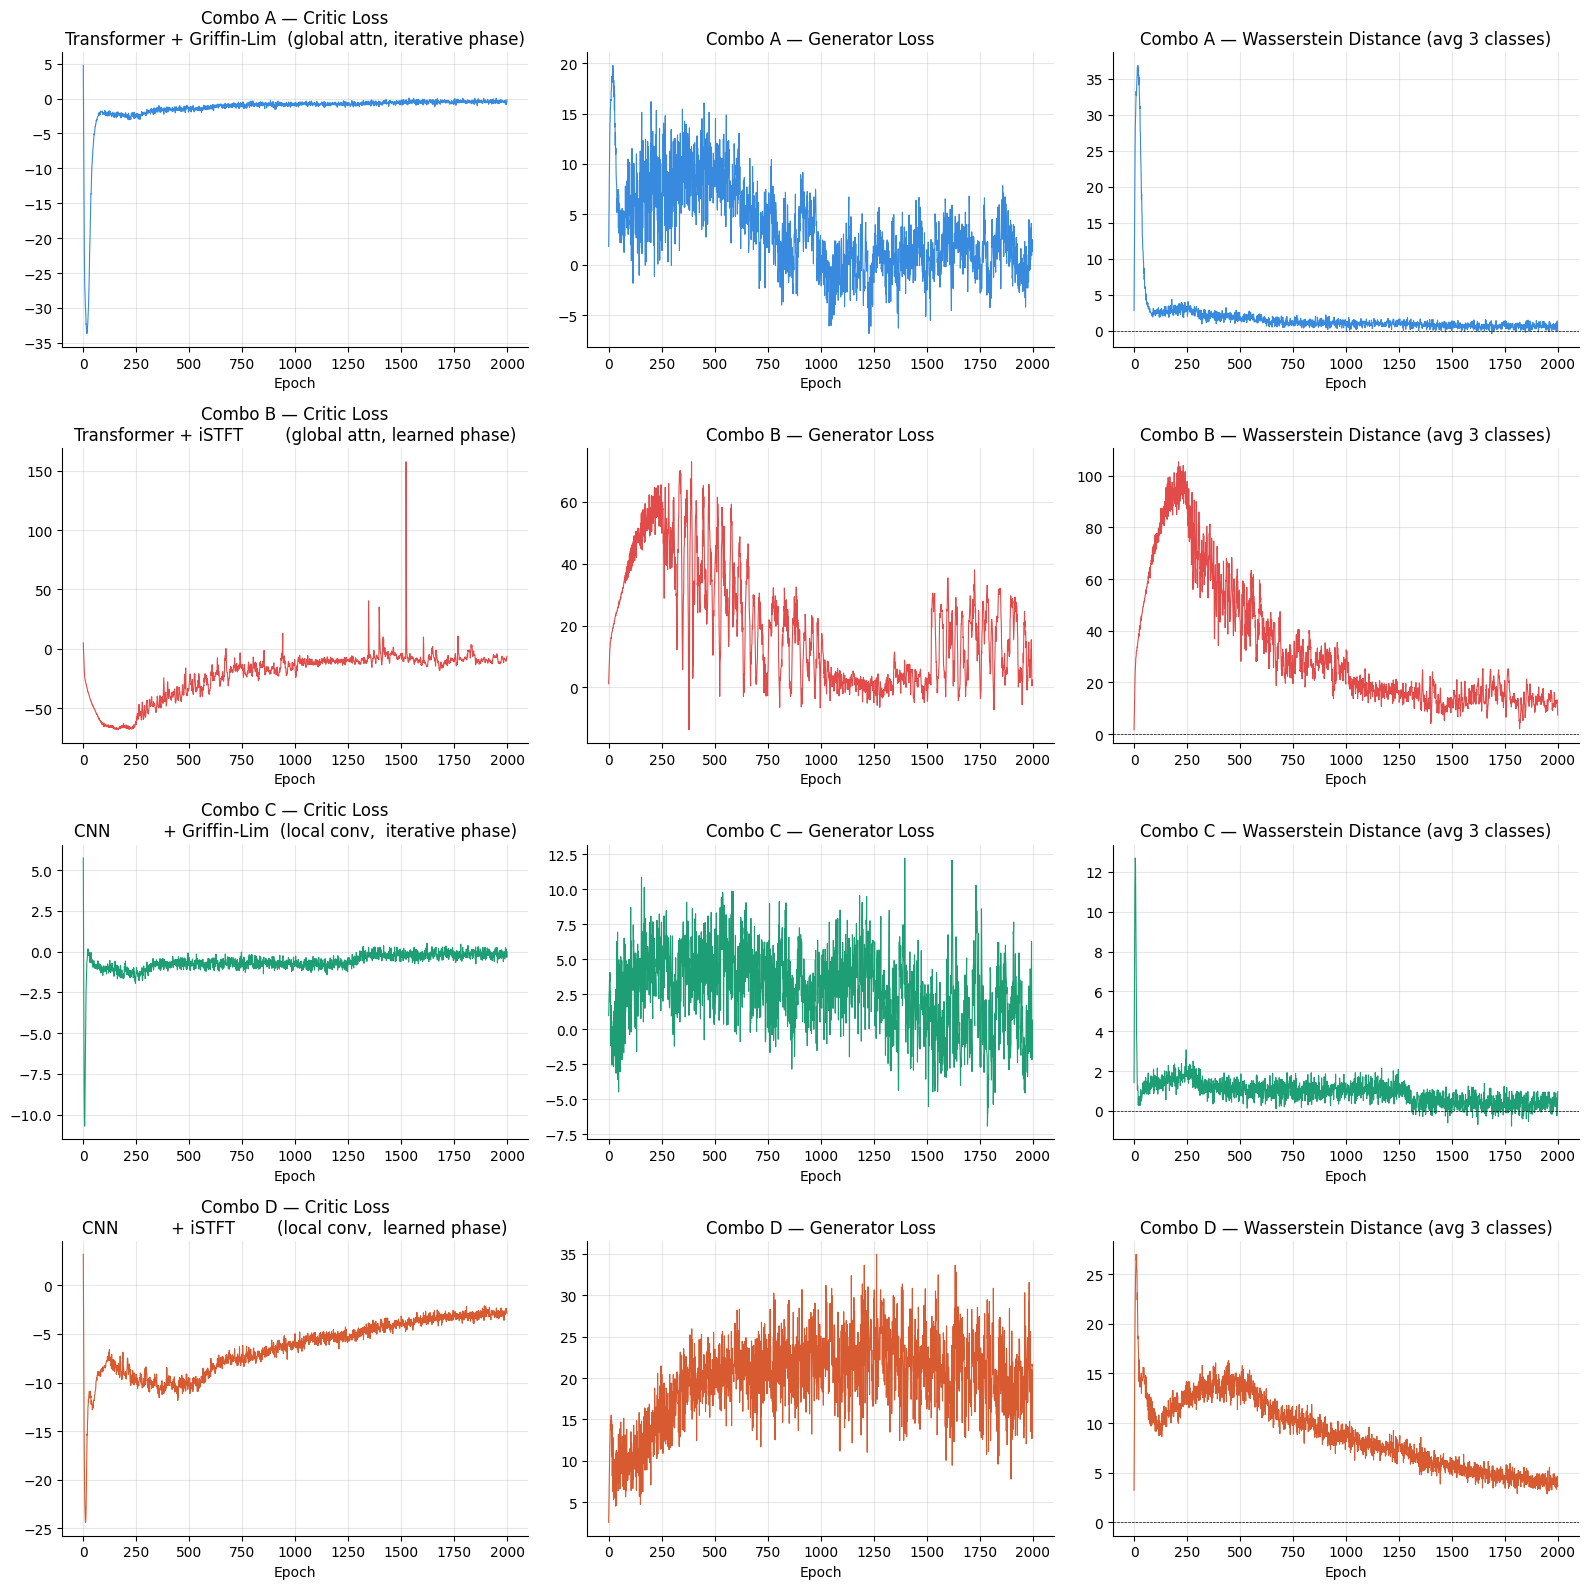

In [ ]:
n_combos = len(ablation_results)
fig, axes = plt.subplots(n_combos, 3, figsize=(16, 4*n_combos))
epochs_ax = np.arange(WGAN_EPOCHS)
combo_colors = {'A':'#378ADD','B':'#E24B4A','C':'#1D9E75','D':'#D85A30'}

for row, (combo_id, _) in enumerate([(c[2],c) for c in COMBOS if c[2] in ablation_results]):
    col_c = combo_colors[combo_id]
    # Average loss across 3 classes
    c_avg  = np.mean([ablation_results[combo_id][cls]['hist']['c'] for cls in TARGET_CLASSES], axis=0)
    g_avg  = np.mean([ablation_results[combo_id][cls]['hist']['g'] for cls in TARGET_CLASSES], axis=0)
    wd_avg = np.mean([ablation_results[combo_id][cls]['hist']['wd'] for cls in TARGET_CLASSES], axis=0)

    desc = next(c[3] for c in COMBOS if c[2]==combo_id)
    axes[row,0].plot(epochs_ax, c_avg, color=col_c, lw=0.8)
    axes[row,0].set_title(f'Combo {combo_id} — Critic Loss\n{desc}')
    axes[row,0].set_xlabel('Epoch')
    axes[row,0].grid(True, alpha=0.3)

    axes[row,1].plot(epochs_ax, g_avg, color=col_c, lw=0.8)
    axes[row,1].set_title(f'Combo {combo_id} — Generator Loss')
    axes[row,1].set_xlabel('Epoch')
    axes[row,1].grid(True, alpha=0.3)

    axes[row,2].plot(epochs_ax, wd_avg, color=col_c, lw=0.8)
    axes[row,2].axhline(0, color='black', lw=0.5, ls='--')
    axes[row,2].set_title(f'Combo {combo_id} — Wasserstein Distance (avg 3 classes)')
    axes[row,2].set_xlabel('Epoch')
    axes[row,2].grid(True, alpha=0.3)

    for ax in axes[row]: ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('loss_curves_ablation.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 14: Distribution Comparison (all combos × all classes)

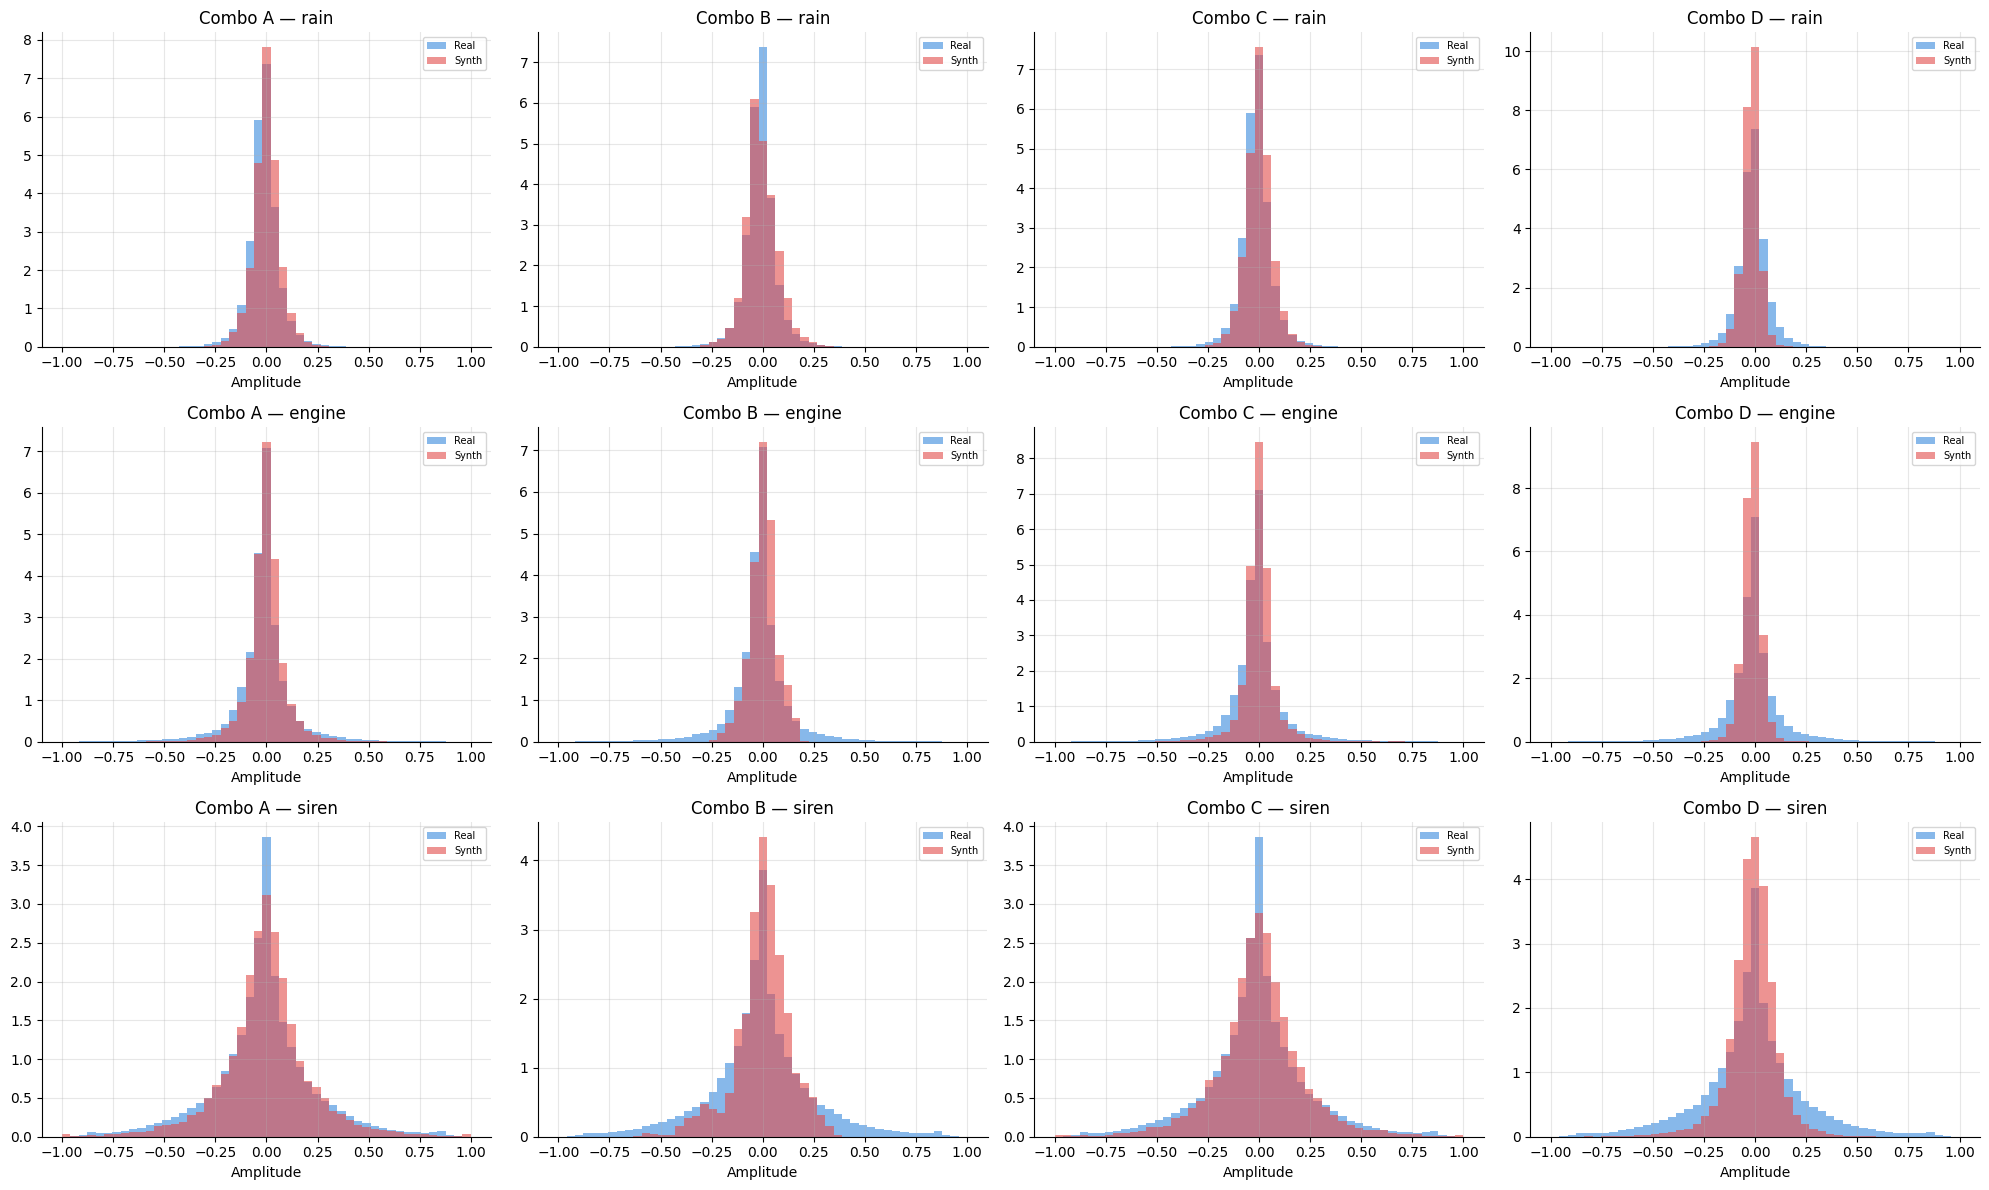

In [ ]:
fig, axes = plt.subplots(N_CLASSES, len(ablation_results),
                          figsize=(5*len(ablation_results), 4*N_CLASSES))
bins = np.linspace(-1, 1, 50)

for col, combo_id in enumerate(ablation_results):
    for row, cls in enumerate(TARGET_CLASSES):
        idx_c = CLASS_IDX[cls]
        rf    = X_train_scaled[y_train == idx_c].flatten()
        sf    = ablation_results[combo_id][cls]['audio'].flatten()
        ax    = axes[row, col]

        ax.hist(rf, bins=bins, alpha=0.6, color='#378ADD',
                label='Real', density=True, edgecolor='none')
        ax.hist(sf, bins=bins, alpha=0.6, color='#E24B4A',
                label='Synth', density=True, edgecolor='none')
        ax.set_title(f'Combo {combo_id} — {cls}')
        ax.set_xlabel('Amplitude')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('distribution_ablation.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 15: Average FFT Comparison (all combos)

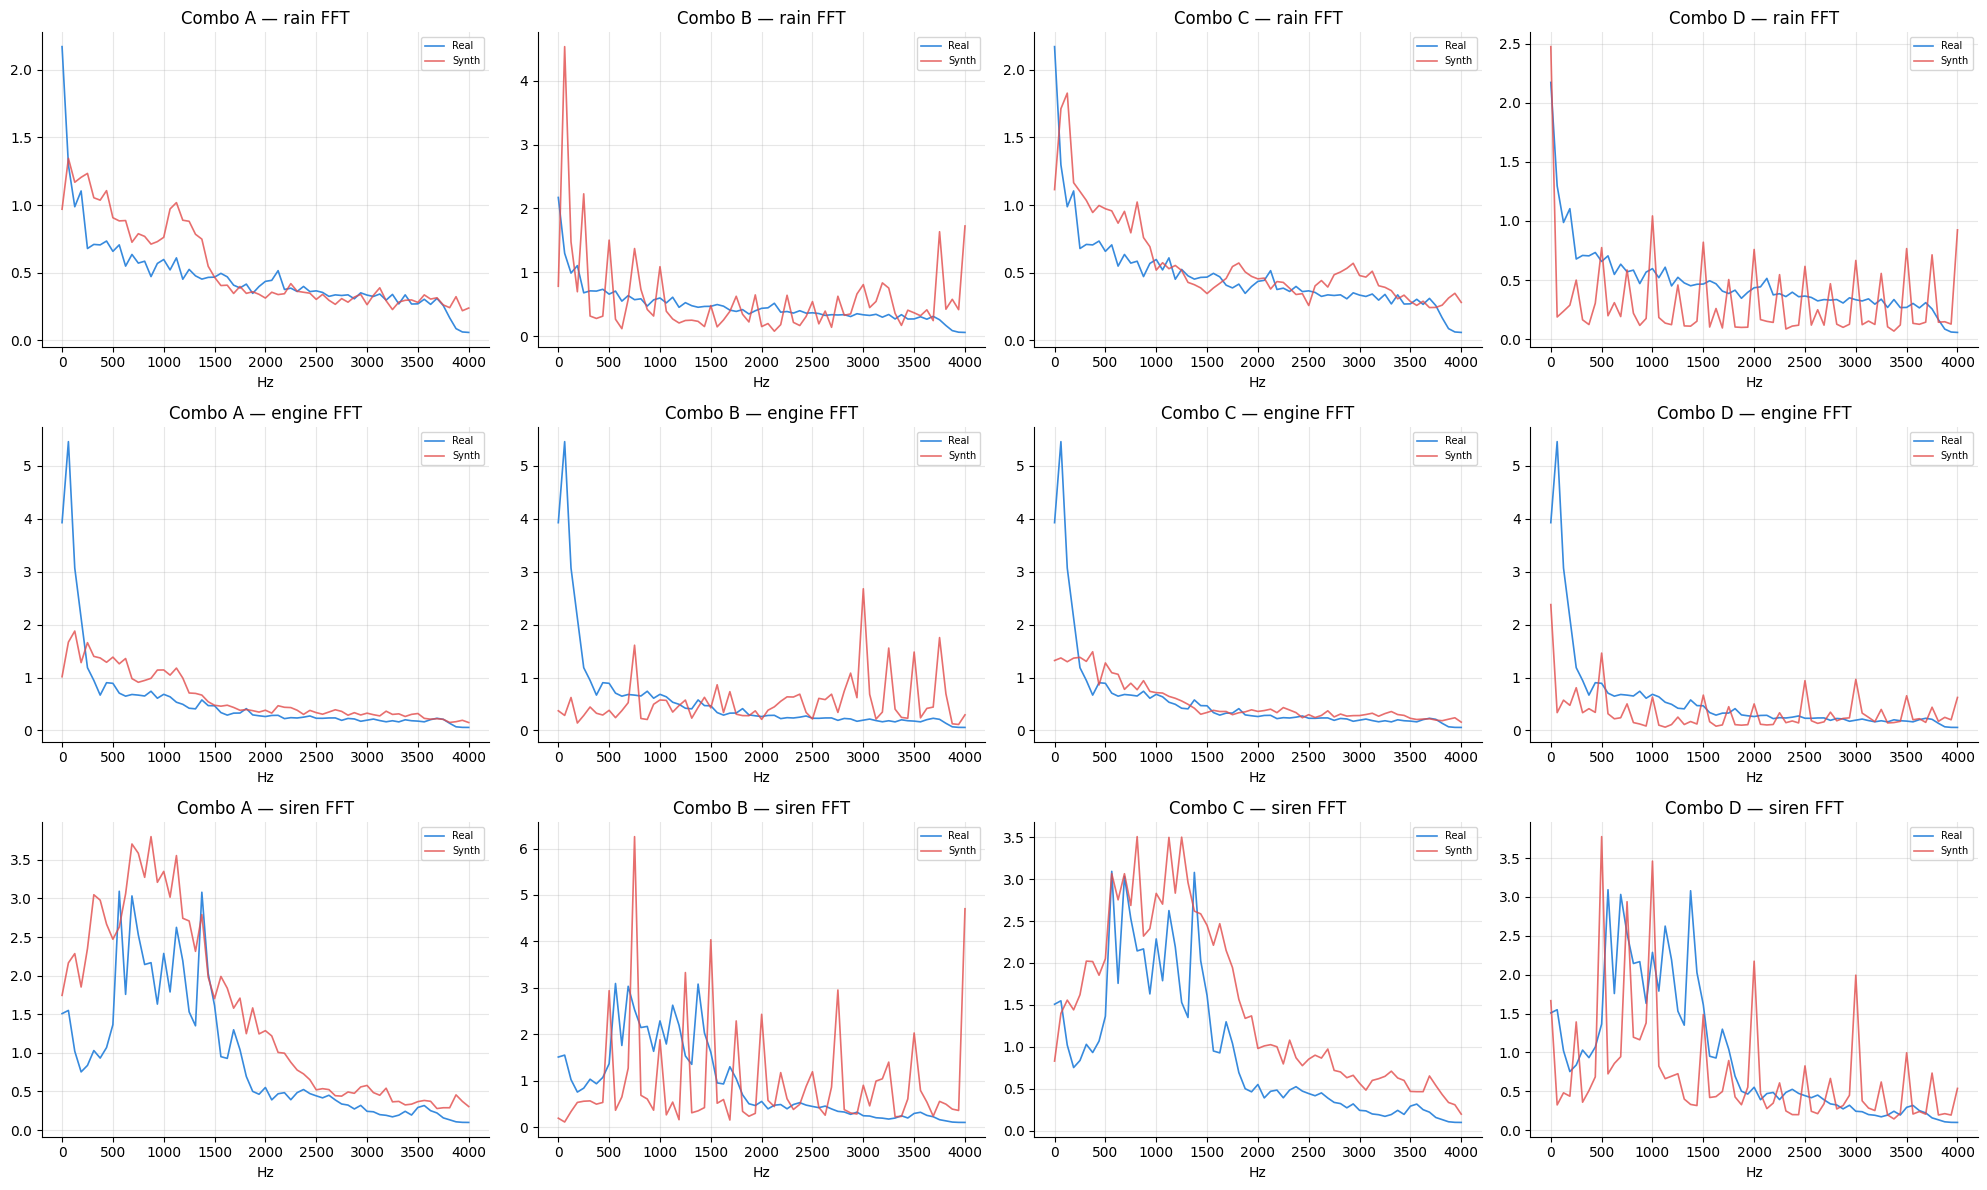

In [ ]:
freqs = np.fft.rfftfreq(SEQ_LEN, d=1.0/TARGET_FS)
fig, axes = plt.subplots(N_CLASSES, len(ablation_results),
                          figsize=(5*len(ablation_results), 4*N_CLASSES))

for col, combo_id in enumerate(ablation_results):
    for row, cls in enumerate(TARGET_CLASSES):
        idx_c   = CLASS_IDX[cls]
        real_td = X_train_scaled[y_train == idx_c]
        syn_td  = ablation_results[combo_id][cls]['audio']

        avg_r = np.mean([np.abs(np.fft.rfft(real_td[i]))
                         for i in range(min(50,len(real_td)))], axis=0)
        avg_s = np.mean([np.abs(np.fft.rfft(syn_td[i]))
                         for i in range(min(50,len(syn_td)))],  axis=0)

        ax = axes[row, col]
        ax.plot(freqs, avg_r, color='#378ADD', lw=1.2, label='Real')
        ax.plot(freqs, avg_s, color='#E24B4A', lw=1.2, label='Synth', alpha=0.8)
        ax.set_title(f'Combo {combo_id} — {cls} FFT')
        ax.set_xlabel('Hz')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fft_ablation.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 16: Classifier — Baseline vs Augmented (each combo)

In [ ]:
from scipy.stats import kurtosis as scipy_kurtosis
from scipy.signal import welch
from scipy.stats import pearsonr

def build_classifier_3class(seq_len=SEQ_LEN, n_classes=N_CLASSES):
    model = tf.keras.Sequential([
        Input(shape=(seq_len, 1)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64,  activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32,  activation='relu'),
        layers.Dense(n_classes, activation='softmax')
    ], name='Clf3')
    model.compile(optimizer=Adam(1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


X_train_clf = X_train_scaled[:, :, np.newaxis]
X_test_clf  = X_test_scaled[:, :, np.newaxis]

# Train baseline ONCE — same for all combos
print('Training baseline classifier (real data only)...')
clf_base = build_classifier_3class()
clf_base.fit(X_train_clf, y_train, epochs=CLF_EPOCHS, batch_size=CLF_BATCH,
             validation_data=(X_test_clf, y_test), verbose=0)
y_pred_base  = np.argmax(clf_base.predict(X_test_clf, verbose=0), axis=1)
baseline_acc = accuracy_score(y_test, y_pred_base)
print(f'Baseline Accuracy: {baseline_acc:.4f}')


# Train augmented classifier for EACH combo
combo_clf_results = {}   # {combo_id: augmented_acc}

for combo_id in ablation_results:
    X_syn_all = np.concatenate([
        ablation_results[combo_id][cls]['audio'][:,:,np.newaxis]
        for cls in TARGET_CLASSES])
    y_syn_all = np.concatenate([
        np.full(N_SYNTHETIC, CLASS_IDX[cls], dtype=np.int32)
        for cls in TARGET_CLASSES])
    X_aug = np.concatenate([X_train_clf, X_syn_all])
    y_aug = np.concatenate([y_train, y_syn_all])
    X_aug, y_aug = sk_shuffle(X_aug, y_aug, random_state=RANDOM_SEED)

    clf_aug = build_classifier_3class()
    clf_aug.fit(X_aug, y_aug, epochs=CLF_EPOCHS, batch_size=CLF_BATCH,
                validation_data=(X_test_clf, y_test), verbose=0)
    y_pred = np.argmax(clf_aug.predict(X_test_clf, verbose=0), axis=1)
    aug_acc = accuracy_score(y_test, y_pred)
    combo_clf_results[combo_id] = {
        'aug_acc':  aug_acc,
        'y_pred':   y_pred,
        'clf':      clf_aug,
    }
    delta = aug_acc - baseline_acc
    sign  = '+' if delta >= 0 else ''
    print(f'  Combo {combo_id}: Augmented={aug_acc:.4f} | delta={sign}{delta:.4f}')

print(f'\nBaseline: {baseline_acc:.4f}')


Training baseline classifier (real data only)...
Baseline Accuracy: 0.7606
  Combo A: Augmented=0.7583 | delta=-0.0022
  Combo B: Augmented=0.7644 | delta=+0.0039
  Combo C: Augmented=0.7572 | delta=-0.0033
  Combo D: Augmented=0.7550 | delta=-0.0056

Baseline: 0.7606


## Step 17: Confusion Matrices (best combo vs baseline)

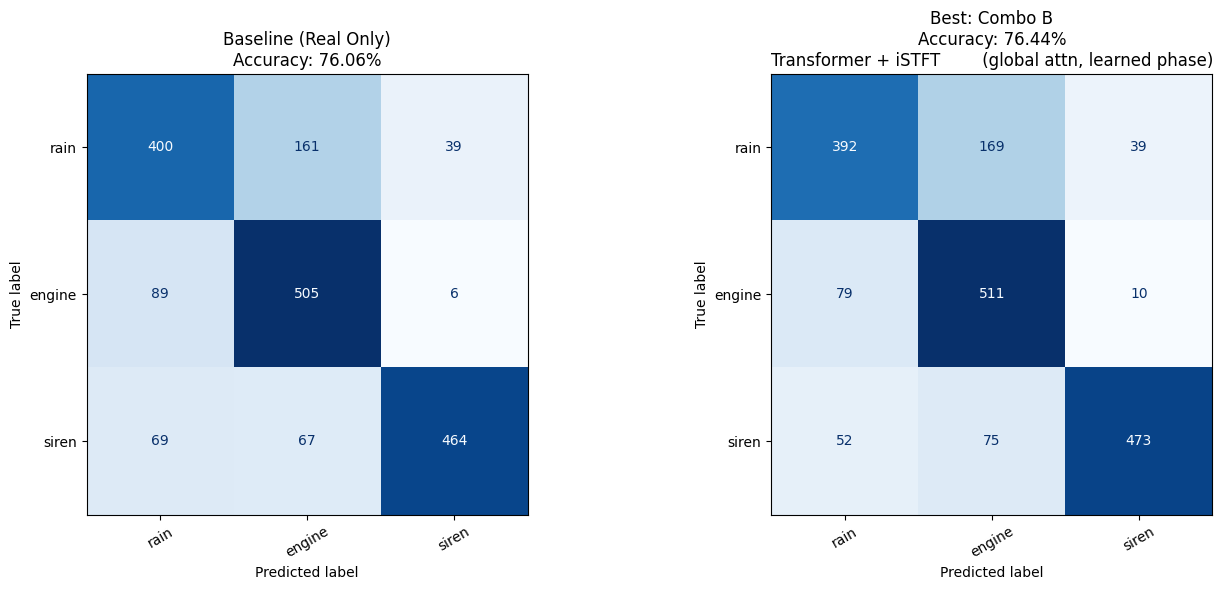

In [ ]:
# Find best combo
best_id  = max(combo_clf_results, key=lambda k: combo_clf_results[k]['aug_acc'])
best_acc = combo_clf_results[best_id]['aug_acc']
best_pred = combo_clf_results[best_id]['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_base),
    display_labels=TARGET_CLASSES).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Baseline (Real Only)\nAccuracy: {baseline_acc:.2%}')
axes[0].tick_params(axis='x', rotation=30)

ConfusionMatrixDisplay(
    confusion_matrix(y_test, best_pred),
    display_labels=TARGET_CLASSES).plot(ax=axes[1], colorbar=False, cmap='Blues')
desc_best = next(c[3] for c in COMBOS if c[2]==best_id)
axes[1].set_title(f'Best: Combo {best_id}\nAccuracy: {best_acc:.2%}\n{desc_best}')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_ablation.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 18: Full Architecture Comparison Table
> Primary comparison across all 4 combos.
> Metrics: RMS error, kurtosis sign match, log-PSD correlation, classifier accuracy improvement.

In [ ]:
print('Computing comparison metrics for all combos...\n')

rows = []
for gen_type, recon_type, combo_id, description in COMBOS:
    if combo_id not in ablation_results:
        continue

    rms_diffs, kurt_signs, psd_corrs = [], [], []

    for cls in TARGET_CLASSES:
        idx_c   = CLASS_IDX[cls]
        real_td = X_train_scaled[y_train == idx_c]
        syn_td  = ablation_results[combo_id][cls]['audio']

        rms_r   = np.sqrt(np.mean(real_td**2, axis=1)).mean()
        rms_s   = np.sqrt(np.mean(syn_td**2,  axis=1)).mean()
        kurt_r  = np.mean([scipy_kurtosis(real_td[i]) for i in range(min(200,len(real_td)))])
        kurt_s  = np.mean([scipy_kurtosis(syn_td[i])  for i in range(len(syn_td))])

        fw, psd_r = welch(real_td.flatten(), fs=TARGET_FS, nperseg=SEQ_LEN)
        _,  psd_s = welch(syn_td.flatten(),  fs=TARGET_FS, nperseg=SEQ_LEN)
        corr, _   = pearsonr(np.log1p(psd_r), np.log1p(psd_s))

        rms_diffs.append(abs(rms_r - rms_s) / (rms_r + 1e-8))
        kurt_signs.append(1 if np.sign(kurt_r) == np.sign(kurt_s) else 0)
        psd_corrs.append(corr)

    aug_acc = combo_clf_results.get(combo_id, {}).get('aug_acc', 0.0)
    delta   = aug_acc - baseline_acc
    rows.append({
        'id':        combo_id,
        'desc':      description,
        'gen_params': build_generator(gen_type, 2 if recon_type=='istft' else 1).count_params(),
        'rms_err':   np.mean(rms_diffs),
        'kurt_ok':   sum(kurt_signs),
        'psd_corr':  np.mean(psd_corrs),
        'aug_acc':   aug_acc,
        'delta':     delta,
    })

# ── Print table ───────────────────────────────────────────────────────────
W = 69
print('='*W)
print('  ARCHITECTURE ABLATION — ESC-50 (rain / engine / siren)')
print('='*W)
print(f'  {"ID":3} | {"Generator":13} | {"Recon":12} | '
      f'{"Params":8} | {"RMS err":8} | {"Kurt 3/3":8} | '
      f'{"PSD corr":8} | {"Aug Acc":8} | {"Delta":7}')
print('-'*W)

gen_labels  = {'transformer':'Transformer','cnn':'CNN'}
recon_labels = {'griffin_lim':'Griffin-Lim','istft':'iSTFT'}

for r in sorted(rows, key=lambda x: -x['aug_acc']):
    combo = next(c for c in COMBOS if c[2]==r['id'])
    gl = gen_labels[combo[0]]
    rl = recon_labels[combo[1]]
    sign = '+' if r['delta']>=0 else ''
    best = ' ← BEST' if r['id'] == max(rows, key=lambda x:x['aug_acc'])['id'] else ''
    print(f"  {r['id']:3} | {gl:13} | {rl:12} | "
          f"{r['gen_params']//1000:5}K   | {r['rms_err']:8.4f} | "
          f"{r['kurt_ok']}/3      | {r['psd_corr']:8.4f} | "
          f"{r['aug_acc']:8.4f} | {sign}{r['delta']:6.4f}{best}")

print('='*W)
print('Metrics: RMS err lower=better | Kurt sign 3/3=best | PSD corr higher=better | Aug Acc higher=better')

print(f'\n  Baseline (no augmentation): {baseline_acc:.4f}')
best_r = max(rows, key=lambda x: x['aug_acc'])
print(f'  Best combo: {best_r["id"]} — {best_r["desc"]}')
print(f'  Best accuracy: {best_r["aug_acc"]:.4f} (delta {best_r["delta"]:+.4f})')

# ── Architecture detail table ─────────────────────────────────────────────
print('\n' + '='*65)
print('  ARCHITECTURE DETAILS')
print('='*65)
details = [
    ('A','Transformer+GL', 'Global attention 256 tokens', 'Iterative 32-iter',   'Slow train, best harmonics'),
    ('B','Transformer+iSTFT','Global attention 256 tokens', 'Single iSTFT call', 'Slow train, best phase'),
    ('C','CNN+GL',         'Local 4→64 upsample Conv',    'Iterative 32-iter',   'Fast train, good local'),
    ('D','CNN+iSTFT',      'Local 4→64 upsample Conv',    'Single iSTFT call',   'Fastest, learned phase'),
]
print(f'  {"ID":3} | {"Label":18} | {"Generator":28} | {"Recon":20} | {"Best for":25}')
print('-'*65)
for d in details:
    print(f'  {d[0]:3} | {d[1]:18} | {d[2]:28} | {d[3]:20} | {d[4]:25}')
print('='*65)


Computing comparison metrics for all combos...

  ARCHITECTURE ABLATION — ESC-50 (rain / engine / siren)
  ID  | Generator     | Recon        | Params   | RMS err  | Kurt 3/3 | PSD corr | Aug Acc  | Delta  
---------------------------------------------------------------------
  B   | Transformer   | iSTFT        |  4381K   |   0.2959 | 1/3      |   0.3791 |   0.7644 | +0.0039 ← BEST
  A   | Transformer   | Griffin-Lim  |  4381K   |   0.0954 | 0/3      |   0.8207 |   0.7583 | -0.0022
  C   | CNN           | Griffin-Lim  |   905K   |   0.1421 | 0/3      |   0.8108 |   0.7572 | -0.0033
  D   | CNN           | iSTFT        |   905K   |   0.4684 | 0/3      |   0.2413 |   0.7550 | -0.0056
Metrics: RMS err lower=better | Kurt sign 3/3=best | PSD corr higher=better | Aug Acc higher=better

  Baseline (no augmentation): 0.7606
  Best combo: B — Transformer + iSTFT        (global attn, learned phase)
  Best accuracy: 0.7644 (delta +0.0039)

  ARCHITECTURE DETAILS
  ID  | Label              | Gen